# 04 — Model Explainability with SHAP
Understanding *why* the model flags a transaction as fraud.

In [2]:
import pandas as pd
import numpy as np
import json, joblib
import matplotlib.pyplot as plt
import shap
shap.initjs()

c:\Users\OJ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

In [6]:
with open('../data/processed/features.json') as f:
    FEATURES = json.load(f)

model = joblib.load('../models/xgboost.pkl')

## SHAP Values — Global Feature Importance

In [ ]:
# Use a sample for speed (SHAP on 100k rows is slow)
sample = X_test.sample(5000, random_state=42)

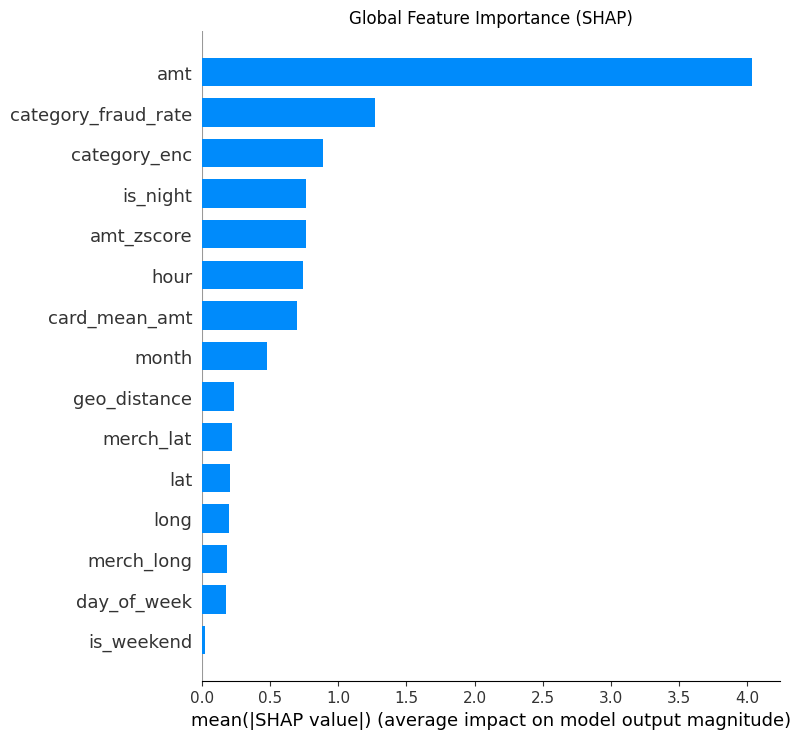

In [8]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

plt.figure()
shap.summary_plot(shap_values, sample, feature_names=FEATURES,
                  plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('../outputs/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Beeswarm Plot

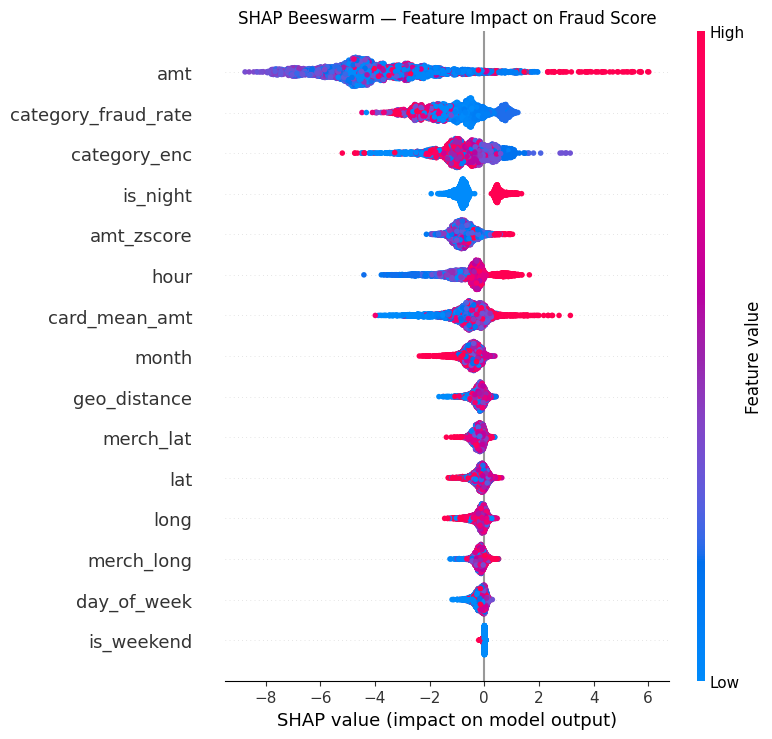

In [9]:
plt.figure()
shap.summary_plot(shap_values, sample, feature_names=FEATURES, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Fraud Score')
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

- Left: reducing fraud score (normal)
- Right: increasing fraud score (sus)
- High value: sus - fraud
- Low value: normal - non-fraud
- Width: crowd of cases

## Single Flagged Transaction Explanation

In [10]:
# Pick a fraud transaction from the test set
fraud_idx   = X_test[y_test == 1].index[0]
txn         = X_test.loc[[fraud_idx]]
fraud_score = model.predict_proba(txn)[0][1]

print(f'Transaction fraud score: {fraud_score:.1%}')
print('\nTransaction details:')
print(txn.T)

Transaction fraud score: 10.2%

Transaction details:
                           1685
amt                   24.840000
hour                  22.000000
day_of_week            6.000000
month                  6.000000
is_weekend             1.000000
is_night               1.000000
geo_distance          80.649140
lat                   31.859900
long                -102.741300
merch_lat             32.575873
merch_long          -102.604290
amt_zscore            -0.383572
card_mean_amt         62.843992
category_enc           5.000000
category_fraud_rate    0.001549


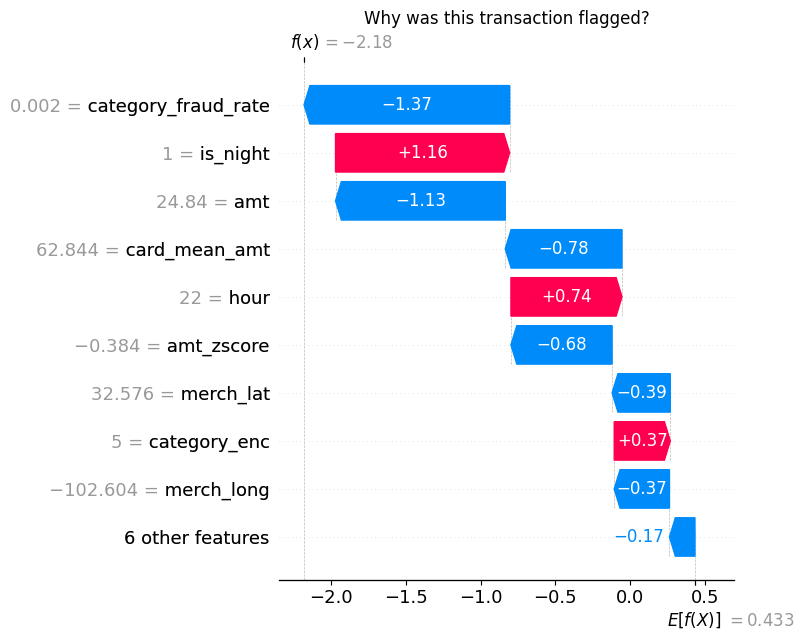

In [11]:
# SHAP waterfall plot for this single transaction
sv_single = explainer(txn)
shap.plots.waterfall(sv_single[0], show=False)
plt.title('Why was this transaction flagged?')
plt.tight_layout()
plt.savefig('../outputs/shap_single_transaction.png', dpi=150, bbox_inches='tight')
plt.show()

## Human-Readable Fraud Explanation

In [12]:
def explain_fraud(txn_row, shap_vals, feature_names, top_n=3):
    """
    Generate a plain-English explanation of why a transaction was flagged.
    """
    sv     = shap_vals[0].values
    top_i  = np.argsort(np.abs(sv))[::-1][:top_n]

    reasons = []
    for i in top_i:
        feat  = feature_names[i]
        val   = txn_row.iloc[0][feat]
        impact = sv[i]
        direction = 'increases' if impact > 0 else 'decreases'

        label_map = {
            'geo_distance':   f'Merchant is {val:.0f} km from your home',
            'amt_zscore':     f'Amount is {val:.1f}x your usual spend',
            'hour':           f'Transaction at {int(val):02d}:00',
            'amt':            f'Transaction amount: ${val:.2f}',
            'is_night':       'Late-night transaction',
            'category_fraud_rate': f'This category has {val:.1%} fraud rate',
        }
        reasons.append(label_map.get(feat, f'{feat} = {val:.2f}'))

    print('FRAUD ALERT')
    print(f'   Fraud probability: {fraud_score:.1%}')
    print('\n   Top reasons:')
    for r in reasons:
        print(f'   • {r}')

sv_single_np = explainer(txn)
explain_fraud(txn, sv_single_np, FEATURES)

FRAUD ALERT
   Fraud probability: 10.2%

   Top reasons:
   • This category has 0.2% fraud rate
   • Late-night transaction
   • Transaction amount: $24.84
